# Email Spam Detection

## Objective

**What is the problem?**
Classifying text messages as either legitimate (Ham) or unsolicited (Spam).

**Why is it useful?**
It is the foundation of email filters and SMS blockers, preventing phishing and clutter.

**Expected outcome.**
A robust NLP model capable of detecting spam with high recall and precision.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

# Download stopwords quietly
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

## Dataset Loading

In [2]:
from IPython.display import display
dataset_path = '../dataset/spam.csv'
if not os.path.exists(dataset_path):
    print('Please place the SMS Spam Collection dataset as spam.csv in the dataset/ folder. Often encoded in latin-1.')
else:
    df = pd.read_csv(dataset_path, encoding='latin-1')
    df = df.iloc[:, :2]  # drop unnamed extra columns
    df.columns = ['label', 'message']
    display(df.head())
    display(df.info())
    print('Null values:', df.isnull().sum())

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


None

Null values: label      0
message    0
dtype: int64


## Class Distribution

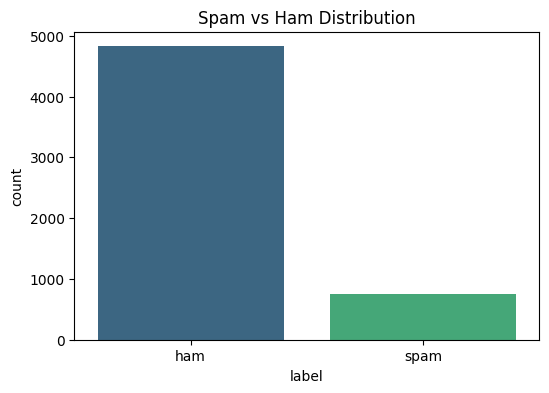

Spam: 13.41%
Ham: 86.59%


In [3]:
if os.path.exists(dataset_path):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='label', palette='viridis')
    plt.title('Spam vs Ham Distribution')
    plt.savefig('../images/class_distribution.png')
    plt.show()
    
    spam_pct = df['label'].value_counts(normalize=True)['spam'] * 100
    ham_pct = df['label'].value_counts(normalize=True)['ham'] * 100
    print(f'Spam: {spam_pct:.2f}%\nHam: {ham_pct:.2f}%')

### Observations
- The dataset is imbalanced. There is a much higher percentage of 'ham' compared to 'spam' messages.

## Text Preprocessing
We clean the text by converting to lowercase, removing punctuation, numbers, and stopwords, and tokenizing.

In [4]:
from IPython.display import display
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # lowercase
    text = re.sub(f'[{string.punctuation}]', '', text) # remove punctuation
    text = re.sub(r'\d+', '', text) # remove numbers
    words = text.split()
    words = [w for w in words if w not in stop_words] # remove stopwords
    return ' '.join(words)

if os.path.exists(dataset_path):
    df['clean_message'] = df['message'].apply(clean_text)
    display(df.head())

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## WordCloud Generation (Bonus)
Visualizing the most frequent words in Spam and Ham messages.

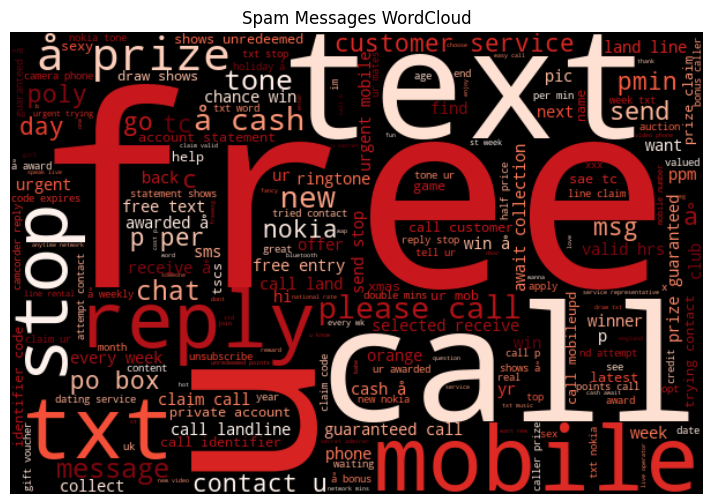

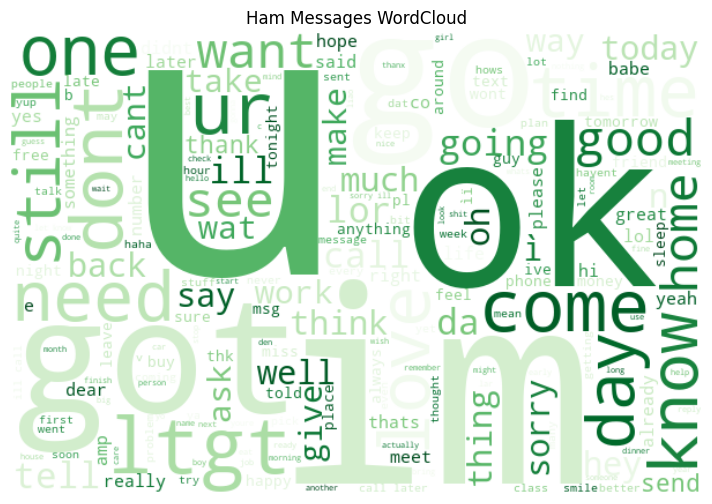

In [5]:
if os.path.exists(dataset_path):
    spam_words = ' '.join(df[df['label'] == 'spam']['clean_message'])
    ham_words = ' '.join(df[df['label'] == 'ham']['clean_message'])
    
    # Spam WordCloud
    spam_wc = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate(spam_words)
    plt.figure(figsize=(10, 6))
    plt.imshow(spam_wc, interpolation='bilinear')
    plt.title('Spam Messages WordCloud')
    plt.axis('off')
    plt.savefig('../images/spam_wordcloud.png')
    plt.show()
    
    # Ham WordCloud
    ham_wc = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(ham_words)
    plt.figure(figsize=(10, 6))
    plt.imshow(ham_wc, interpolation='bilinear')
    plt.title('Ham Messages WordCloud')
    plt.axis('off')
    plt.savefig('../images/ham_wordcloud.png')
    plt.show()

### Observations
- Spam messages heavily feature words like 'free', 'call', 'txt', 'reply', 'prize'.
- Ham messages feature conversational words like 'u', 'gt', 'lt', 'ok', 'come'.

## TF-IDF (Term Frequency-Inverse Document Frequency)
TF-IDF transforms text into numerical vectors. It evaluates how relevant a word is to a document in a collection. It increases proportionally to the number of times a word appears in the document but is offset by the number of documents that contain the word, helping to adjust for the fact that some words appear more frequently in general.

In [6]:
if os.path.exists(dataset_path):
    tfidf = TfidfVectorizer(max_features=3000)
    X = tfidf.fit_transform(df['clean_message']).toarray()
    y = df['label'].map({'ham': 0, 'spam': 1})
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training
Training Multinomial Naive Bayes (standard for text), Logistic Regression, and Linear SVM.

In [7]:
if os.path.exists(dataset_path):
    models = {
        'Naive Bayes': MultinomialNB(),
        'Logistic Regression': LogisticRegression(),
        'Linear SVM': LinearSVC()
    }
    results = {}

## Model Evaluation

--- Naive Bayes ---
Accuracy: 0.9758 | Precision: 1.0000 | Recall: 0.8200 | F1 Score: 0.9011


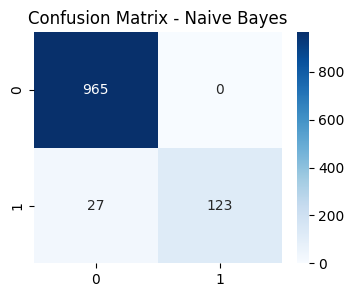

--- Logistic Regression ---
Accuracy: 0.9525 | Precision: 0.9619 | Recall: 0.6733 | F1 Score: 0.7922


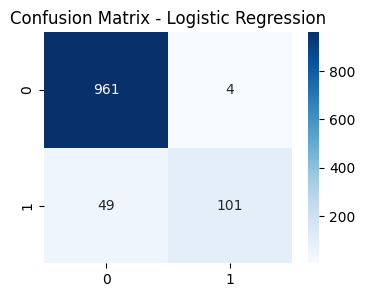

--- Linear SVM ---
Accuracy: 0.9776 | Precision: 0.9771 | Recall: 0.8533 | F1 Score: 0.9110


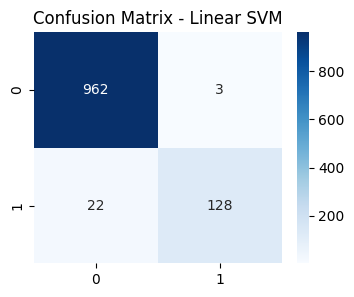

In [8]:
if os.path.exists(dataset_path):
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results[name] = f1
        
        print(f'--- {name} ---')
        print(f'Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1 Score: {f1:.4f}')
        
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
        plt.title(f'Confusion Matrix - {name}')
        plt.savefig(f'../images/cm_{name.replace(" ", "_")}.png')
        plt.show()

In [ ]:
if os.path.exists(dataset_path):
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(results.keys()), y=list(results.values()), palette='mako')
    plt.title('Model Comparison: F1 Score')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1.1)
    for i, v in enumerate(results.values()):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
    plt.savefig('../images/model_f1_comparison.png')
    plt.show()


### Why Recall is Critical in Spam Detection
In spam detection, Precision ensures we don't accidentally send important emails (Ham) to the Spam folder (False Positives). However, **Recall** is critical to ensure that actual spam gets caught (minimizing False Negatives). Depending on user preference, balancing the two (F1 Score) is ideal, but a high precision system is usually preferred to avoid missing crucial personal emails.

## Save Best Model

In [9]:
if os.path.exists(dataset_path):
    best_model_name = max(results, key=results.get)
    best_model = models[best_model_name]
    joblib.dump(best_model, '../models/best_spam_model.pkl')
    joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
    print(f'Best model ({best_model_name}) and TF-IDF vectorizer saved to models/')

Best model (Linear SVM) and TF-IDF vectorizer saved to models/


## Conclusion
- SVM and Naive Bayes performed exceptionally well on this text dataset.
- Proper text preprocessing and TF-IDF vectorization were key to separating the classes.
- **Future Improvements**: Try advanced embeddings (Word2Vec, BERT) for complex contextual spam.